In [1]:
# Restore the path to the plots directory
%store -r plots_dir

In [ ]:
# Import the below libraries:
"""For faster loading, consider importing the libraries in separate cells."""
# To create reproducible file paths
import os # To interact with the operating system
from pathlib import Path # To create Path objects
import pathlib # To access the object-oriented library for paths

# To work with different types of data
import numpy as np # To work with arrays
import openpyxl # To read XLSX files
import pandas as pd # To work with dataframes

# For visualization and interactive plotting
import matplotlib.pyplot as plt # To import the Pyplot module
from matplotlib.ticker import PercentFormatter # To format percentages

In [3]:
# Create a designated folder for the organism nutrient data
"""Note: the precise destination of the repository folder will vary from individual to individual."""
organism_nutrient_dir = os.path.join(
    pathlib.Path.home(),
    # In the earth-analytics data folder
    'earth-analytics',
    'data',
    # Specify the destination as inside the "PLANT-B-Stoichiometric-Nutrient-Cycle-Simulation" data repository
    'PLANT-B-Stoichiometric-Nutrient-Cycle-Simulation',
    'data',
    'stoichiometry_variables'
)

# Create the directory
os.makedirs(organism_nutrient_dir, exist_ok=True)

It is not possible to download the appropriate files through a Python function because the Dryad server uses a proof-of-work JavaScript check that interrupts non-browser requests. The dataset and README file must be manually downloaded from https://datadryad.org/dataset/doi:10.5061/dryad.3tx95x6r2 and moved to "stoichlife_dir," which is created in the cell below. 

In [4]:
# Create a specific directory for the StoichLife data
stoichlife_dir = os.path.join(organism_nutrient_dir, 'stoichlife_data')
os.makedirs(stoichlife_dir, exist_ok=True)

# Define the file path to the XLSX file
stoichlife_path = os.path.join(stoichlife_dir, "datapaper_2025_02_11.xlsx")

# Save the "data" sheet of the XLSX file as a dataframe
"""The XLSX file also contains a "metadata" and "references" sheet. The "metadata" sheet details what the variables (ex. habitat) are
describing."""
stoichlife_df = pd.read_excel(stoichlife_path, sheet_name="data")

# Display the data
stoichlife_df

,data.source1,data.type,data.provider1,lat.dec,long.dec,location,habitat.gen,habitat,kingdom_init,phylum_init,...,taxa.np,taxa.mass.cn,taxa.mass.cp,taxa.mass.np,body.weight.gr,temperature,radiation,N,P_ter,P_mar
0,unpublished - Alfaro,template,Alfaro,-20.105400,-67.330000,-20.1054 -67.33,terrestrial,terrestrial,Animalia,Arthropoda,...,149.717942,NaN,NaN,67.705882,0.000628,7.46,6.20,60.439308,43.495975,0.782
1,unpublished - Alfaro,template,Alfaro,-20.105400,-67.330000,-20.1054 -67.33,terrestrial,terrestrial,Animalia,Arthropoda,...,54.923883,4.548422,112.972973,24.837838,0.000431,7.46,6.20,60.439308,43.495975,0.782
2,Benstead et al. 2010,paper,NaN,18.159600,-65.982700,18.1596 -65.9827,aquatic,freshwater,Animalia,Arthropoda,...,27.617712,4.126065,51.531915,12.489362,0.199900,26.41,5.78,104.139830,18.790420,0.067
3,Benstead et al. 2010,paper,NaN,18.159600,-65.982700,18.1596 -65.9827,aquatic,freshwater,Animalia,Arthropoda,...,23.249069,4.092496,43.027523,10.513761,0.097500,26.41,5.78,104.139830,18.790420,0.067
4,Benstead et al. 2010,paper,NaN,18.316940,-65.746670,18.31694 -65.74667,aquatic,freshwater,Animalia,Arthropoda,...,25.642952,3.636076,42.165138,11.596330,0.109600,26.41,5.78,104.139830,21.631483,0.067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28044,unpublished - Roussel,template,Roussel,-49.275057,70.114103,-49.275057 70.114103,aquatic,freshwater,Animalia,Chordata,...,NaN,3.524021,NaN,NaN,0.000303,3.61,3.25,19.262070,NaN,1.659
28045,unpublished - Roussel,template,Roussel,-49.275057,70.114103,-49.275057 70.114103,aquatic,freshwater,Animalia,Chordata,...,NaN,3.538794,NaN,NaN,0.000287,3.61,3.25,19.262070,NaN,1.659
28046,unpublished - Roussel,template,Roussel,-49.275057,70.114103,-49.275057 70.114103,aquatic,freshwater,Animalia,Chordata,...,NaN,3.434890,NaN,NaN,0.000290,3.61,3.25,19.262070,NaN,1.659
28047,unpublished - Roussel,template,Roussel,-49.275057,70.114103,-49.275057 70.114103,aquatic,freshwater,Animalia,Chordata,...,NaN,3.443535,NaN,NaN,0.000312,3.61,3.25,19.262070,NaN,1.659


In [5]:
# Look at the columns
stoichlife_df.columns

Index(['data.source1', 'data.type', 'data.provider1', 'lat.dec', 'long.dec',
       'location', 'habitat.gen', 'habitat', 'kingdom_init', 'phylum_init',
       'class_init', 'order_init', 'family_init', 'sp.morphosp_init',
       'kingdom_revised', 'phylum_revised', 'class_revised', 'order_revised',
       'family_revised', 'sp.morphosp_revised', 'species.level', 'autohetero',
       'invert.vert.auto', 'taxa.c', 'taxa.n', 'taxa.p', 'taxa.cn', 'taxa.cp',
       'taxa.np', 'taxa.mass.cn', 'taxa.mass.cp', 'taxa.mass.np',
       'body.weight.gr', 'temperature', 'radiation', 'N', 'P_ter', 'P_mar'],
      dtype='str')

# Columns to Keep Definitions

The below definitions were derived from the metadata tab:
* sp.morphosp_revised: Currently accepted species taxonomy
* class_revised: Currently accepted class taxonomy
* family_revised: Currently accepted family taxonomy
* habitat: Differentiates terrestrial, aquatic, and marine habitats
* taxa.c: Carbon content of organisms by percentage (%)
* taxa.n: Nitrogen content of organisms by percentage (%)
* taxa.p: Phosphorus content of organisms by percentage (%)
* taxa.cn: Carbon-nitrogen ratio (C:N) in an organism's body 
* taxa.cp: Carbon-phosphorus ratio (C:P)  in an organism's body
* taxa.np: Nitrogen-phosphorus ratio (N:P) in an organism's body
* taxa.mass.cn: C:N of organisms as mass ratios (C%/N%)
* taxa.mass.cp: C:P of organisms as mass ratios (C%/N%)
* taxa.mass.np: N:P of organisms as mass ratios (N%/P%)
* body.weight.gr: Body dry mass in grams (g)
* N: Global nitrogen availability data
* P_ter: Soil phosphorus data from the Oak Ridge National Laboratories Distributed Active Archive Center

Source: (González et al., 2025)

In [6]:
# Specify the columns to keep
"""Only columns related to the species's species name and family name and nutrient data will be kept."""
columns_to_keep = ['sp.morphosp_revised', 'class_revised', 'family_revised', 'habitat', 'taxa.c', 'taxa.n', 'taxa.p', 'taxa.cn', 'taxa.cp', 'taxa.np', 'taxa.mass.cn', 
                   'taxa.mass.cp', 'taxa.mass.np', 'body.weight.gr', 'N', 'P_ter']

# Filter the dataset to keep only the necessary columns
stoichlife_filtered_df = stoichlife_df[columns_to_keep]

# Display the filtered dataframe
stoichlife_filtered_df

,sp.morphosp_revised,class_revised,family_revised,habitat,taxa.c,taxa.n,taxa.p,taxa.cn,taxa.cp,taxa.np,taxa.mass.cn,taxa.mass.cp,taxa.mass.np,body.weight.gr,N,P_ter
0,Formicidae sp.11,Insecta,Formicidae,terrestrial,NaN,11.510000,0.17,NaN,NaN,149.717942,NaN,NaN,67.705882,0.000628,60.439308,43.495975
1,Formicidae sp.9,Insecta,Formicidae,terrestrial,41.800000,9.190000,0.37,5.304302,291.332886,54.923883,4.548422,112.972973,24.837838,0.000431,60.439308,43.495975
2,Atya lanipes,Malacostraca,Atyidae,freshwater,48.440000,11.740000,0.94,4.811755,132.889673,27.617712,4.126065,51.531915,12.489362,0.199900,104.139830,18.790420
3,Xiphocaris elongata,Malacostraca,Xiphocarididae,freshwater,46.900000,11.460000,1.09,4.772608,110.958684,23.249069,4.092496,43.027523,10.513761,0.097500,104.139830,18.790420
4,Xiphocaris elongata,Malacostraca,Xiphocarididae,freshwater,45.960000,12.640000,1.09,4.240338,108.734779,25.642952,3.636076,42.165138,11.596330,0.109600,104.139830,21.631483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28044,Salvelinus fontinalis,Actinopterygii,Salmonidae,freshwater,44.493203,12.625693,NaN,4.109661,NaN,NaN,3.524021,NaN,NaN,0.000303,19.262070,NaN
28045,Salvelinus fontinalis,Actinopterygii,Salmonidae,freshwater,44.234026,12.499746,NaN,4.126889,NaN,NaN,3.538794,NaN,NaN,0.000287,19.262070,NaN
28046,Salvelinus fontinalis,Actinopterygii,Salmonidae,freshwater,44.730870,13.022505,NaN,4.005717,NaN,NaN,3.434890,NaN,NaN,0.000290,19.262070,NaN
28047,Salvelinus fontinalis,Actinopterygii,Salmonidae,freshwater,45.114385,13.101184,NaN,4.015799,NaN,NaN,3.443535,NaN,NaN,0.000312,19.262070,NaN


In [7]:
# Filter 'sp.morphosp_revised' for close relatives of the invertebrates
invertebrate_df = stoichlife_filtered_df[stoichlife_filtered_df['sp.morphosp_revised'].isin(['Folsomia fimetaria', 'Platyarthrus sp.'])]

# Display the filtered dataframe
invertebrate_df

,sp.morphosp_revised,class_revised,family_revised,habitat,taxa.c,taxa.n,taxa.p,taxa.cn,taxa.cp,taxa.np,taxa.mass.cn,taxa.mass.cp,taxa.mass.np,body.weight.gr,N,P_ter
22490,Folsomia fimetaria,Collembola,Isotomidae,terrestrial,39.13,9.561228,NaN,4.772695,NaN,NaN,4.092570,NaN,NaN,NaN,1626.260452,16.725162
22505,Folsomia fimetaria,Collembola,Isotomidae,terrestrial,39.26,9.792730,NaN,4.675349,NaN,NaN,4.009097,NaN,NaN,NaN,1626.260452,16.725162
25347,Platyarthrus sp.,Malacostraca,Platyarthridae,terrestrial,NaN,1.160000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1060.043928,66.802081


In [8]:
# Average the C:N ratio for the chosen springtail species
springtail_c_n_ratio = invertebrate_df.loc[invertebrate_df['sp.morphosp_revised'] == 'Folsomia fimetaria', 'taxa.cn'].mean()

# Print the C:N ratio
print(springtail_c_n_ratio)

4.72402186718267


In [9]:
# Create variables for the average springtail carbon and nitrogen for later use
springtail_c = invertebrate_df.loc[invertebrate_df['sp.morphosp_revised'] == 'Folsomia fimetaria', 'taxa.c'].mean() # For carbon
springtail_n = invertebrate_df.loc[invertebrate_df['sp.morphosp_revised'] == 'Folsomia fimetaria', 'taxa.n'].mean() # For nitrogen

In [10]:
# Create a variable for the isopod nitrogen body percentage
isopod_n = invertebrate_df.loc[invertebrate_df['sp.morphosp_revised'] == 'Platyarthrus sp.', 'taxa.n'].iloc[0]

# Display the isopod nitrogen body percentage
print(isopod_n)

1.16


In [11]:
# Filter for close relatives of the isopod that have a carbon body mass percentage less than 21%
isopod_c = stoichlife_filtered_df.loc[
    (stoichlife_filtered_df['sp.morphosp_revised'] == 'Trichoniscus pusillus') & (stoichlife_filtered_df['taxa.c'] < 21), 'taxa.c'].iloc[0]

# Display the isopod carbon body percentage
print(isopod_c)

20.74


In [12]:
# Calculate the isopod C:N ratio
isopod_c_n_ratio = isopod_c / isopod_n

# Print the ratio
print(isopod_c_n_ratio)

17.879310344827587


In [13]:
# Filter for terrestrial mosses in the order Bryopsida that have nitrogen data
moss_df = stoichlife_filtered_df[
    (stoichlife_filtered_df['class_revised'] == 'Bryopsida') &
    (stoichlife_filtered_df['habitat'] == 'terrestrial') &
    (stoichlife_filtered_df['taxa.n'].notna())
]

# Display the dataframe
moss_df

,sp.morphosp_revised,class_revised,family_revised,habitat,taxa.c,taxa.n,taxa.p,taxa.cn,taxa.cp,taxa.np,taxa.mass.cn,taxa.mass.cp,taxa.mass.np,body.weight.gr,N,P_ter
17795,Ctenidium molluscum,Bryopsida,Hypnaceae,terrestrial,NaN,1.90,0.090,NaN,NaN,46.682976,NaN,NaN,21.111111,NaN,NaN,NaN
17912,Bryum argenteum,Bryopsida,Bryaceae,terrestrial,NaN,1.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17913,Bryum capillare,Bryopsida,Bryaceae,terrestrial,NaN,1.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17914,Ceratodon purpureus,Bryopsida,Ditrichaceae,terrestrial,NaN,1.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17927,Grimmia pulvinata,Bryopsida,Grimmiaceae,terrestrial,NaN,1.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17928,Homalothecium sericeum,Bryopsida,Brachytheciaceae,terrestrial,NaN,2.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17929,Hypnum cupressiforme,Bryopsida,Hypnaceae,terrestrial,NaN,1.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17942,Racomitrium lanuginosum,Bryopsida,Grimmiaceae,terrestrial,NaN,0.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17944,Tortula muralis,Bryopsida,Pottiaceae,terrestrial,NaN,1.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18046,Calliergonella cuspidata,Bryopsida,Amblystegiaceae,terrestrial,NaN,1.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Calculate the average nitrogen percentage in the mosses
moss_n = moss_df['taxa.n'].mean()

# State the average carbon content for the model moss
"""Note: The bonfire moss (Funaria hygrometrica), a close relative of P. patens, has an average carbon dry mass content of 44.4% (
https://www.sciencedirect.com/topics/agricultural-and-biological-sciences/funaria-hygrometrica)."""
moss_c = 44.4

# Calculate the C:N ratio for the moss
moss_c_n_ratio = moss_c / moss_n

# Print the ratio
print(moss_c_n_ratio)

35.141087405368204


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Elemental Composition of PLANT-B Species by Percent Dry Mass'}, xlabel='Species', ylabel='Percent Dry Mass (%)'>)

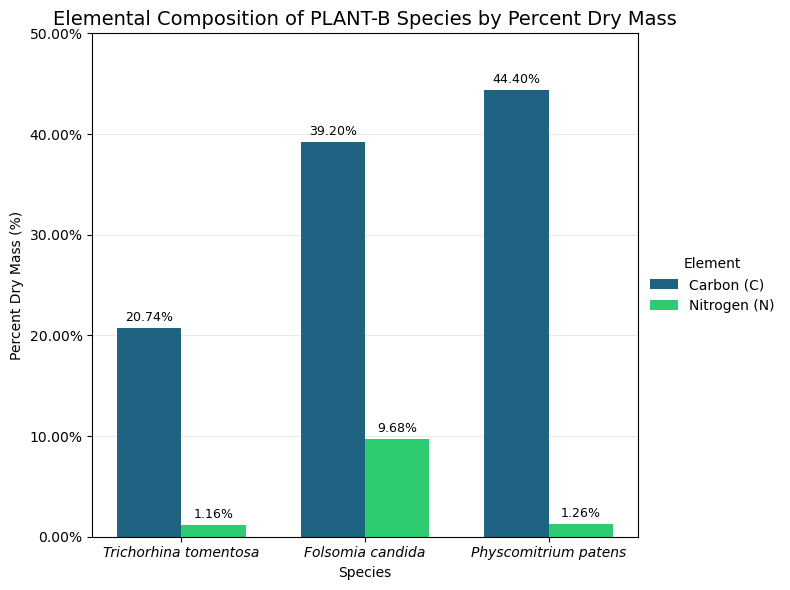

In [15]:
# Create a dictionary that groups the numeric values by species and element
species_elemental_variables = {
    'Trichorhina tomentosa': {'Carbon (C)': isopod_c, 'Nitrogen (N)': isopod_n},
    'Folsomia candida': {'Carbon (C)': springtail_c, 'Nitrogen (N)': springtail_n},
    'Physcomitrium patens': {'Carbon (C)': moss_c, 'Nitrogen (N)': moss_n},
}

# Create a function generates a grouped bar chart of elemental composition by percent dry mass for each PLANT-B species:
def plot_elemental_composition(species_elemental_variables):
    """
    Parameters:
    species_elemental_variables (dict): A dictionary that groups elemental composition by species and element

    Returns:
    Grouped bar chart
    """
    # Extract the species and element names from the dictionary
    species = list(species_elemental_variables.keys())
    carbon = [species_elemental_variables[sp]['Carbon (C)'] for sp in species]
    nitrogen = [species_elemental_variables[sp]['Nitrogen (N)'] for sp in species]

     # Set the bar positions and width
    x = np.arange(len(species))
    width = 0.35

    # Create the figure and plotting surface
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the carbon and nitrogen bars and set their colors
    carbon_bars = ax.bar(x - width/2, carbon, width, label='Carbon (C)', color='#1F6382') # Color the carbon bars dark turquoise
    nitrogen_bars = ax.bar(x + width/2, nitrogen, width, label='Nitrogen (N)', color='#2ECC71') # Color the nitrogen bars bright green

    # Format the titles and axes labels
    ax.set_title('Elemental Composition of PLANT-B Species by Percent Dry Mass', fontsize=14) # Set the plot title
    ax.set_xlabel('Species') # Set the x-axis label
    ax.set_ylabel('Percent Dry Mass (%)') # Set the y-axis label
    ax.set_xticks(x) # Group the labels correctly
    ax.set_xticklabels(species, style='italic') # Italicize the species names

    # Format the y-axis as a percentage
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=2))
    ax.set_ylim(0, 50)
    ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.4)
    ax.set_axisbelow(True)

    # Create a legend titled "Element" and anchor it to the right
    ax.legend(title='Element', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

    # Add value labels above each bar
    for bars in [carbon_bars, nitrogen_bars]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}%',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
            
    # Apply a tight layout
    plt.tight_layout()

    # Save the plot as a png image to the "plots" folder
    plt.savefig(
        os.path.join(plots_dir, "PLANT-B_Species_Dry_Mass_Elemental_Composition.png"),
        dpi=300,
        bbox_inches="tight"
    )

    # Return the figure and axes
    return fig, ax

# Call the function
plot_elemental_composition(species_elemental_variables)

In [16]:
%store isopod_c_n_ratio springtail_c_n_ratio moss_c_n_ratio

Stored 'isopod_c_n_ratio' (float64)
Stored 'springtail_c_n_ratio' (float64)
Stored 'moss_c_n_ratio' (float64)
